In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
import pickle
from sklearn.utils.class_weight import compute_class_weight
import random

In [2]:
####Configurations

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
DATA_PATH = "Data segrigation_Augmented"
NUM_CLASSES = 7

CLASS_NAMES = [
    'Bacteria Blight',
    'Brown spot',
    'Caterpillar Damage',
    'Dry',
    'Kanamadiri haniya',
    'Leaf spot',
    'Red Spider mite Damage'
]

In [4]:
# Create save directories
os.makedirs("saved_models-1", exist_ok=True)
os.makedirs("training_history-1", exist_ok=True)

# Set seeds
tf.random.set_seed(42)
np.random.seed(42)

print("Hybrid VGG16 + DenseNet121 Model for Betel Leaf Disease")
print(f"Classes: {CLASS_NAMES}")

Hybrid VGG16 + DenseNet121 Model for Betel Leaf Disease
Classes: ['Bacteria Blight', 'Brown spot', 'Caterpillar Damage', 'Dry', 'Kanamadiri haniya', 'Leaf spot', 'Red Spider mite Damage']


In [5]:
####DATA GENERATORS

In [6]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}\n")

# Class weights (very important for your imbalanced data)
class_weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights applied to handle imbalance.\n")

Found 3684 images belonging to 7 classes.
Found 917 images belonging to 7 classes.
Training samples: 3684
Validation samples: 917

Class weights applied to handle imbalance.



In [7]:
#####HYBRID MODEL: VGG16 + DenseNet121

In [8]:
def create_hybrid_model():
    vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    dense = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

    # Fine-tuning: unfreeze last few layers
    for layer in vgg.layers[:-6]: layer.trainable = False
    for layer in dense.layers[:-25]: layer.trainable = False

    inputs = layers.Input(shape=(224,224,3))

    # Two powerful branches
    x1 = vgg(inputs)
    x1 = layers.GlobalAveragePooling2D()(x1)
    x1 = layers.Dense(512, activation='relu')(x1)
    x1 = layers.Dropout(0.5)(x1)

    x2 = dense(inputs)
    x2 = layers.GlobalAveragePooling2D()(x2)
    x2 = layers.Dense(512, activation='relu')(x2)
    x2 = layers.Dropout(0.5)(x2)

    # Fusion
    merged = layers.Concatenate()([x1, x2])
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dense(1024, activation='relu')(merged)
    merged = layers.Dropout(0.6)(merged)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(merged)

    model = Model(inputs, outputs, name="Hybrid_VGG16_DenseNet121")
    return model

model = create_hybrid_model()
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
##CALLBACKS

In [10]:
TFLITE_MODEL_PATH = "CNN_Disease.tflite"

class TFLiteSaveCallback(Callback):
    def __init__(self, filepath, monitor='val_accuracy', verbose=1):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.verbose = verbose
        self.best = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return

        if current > self.best:
            self.best = current
            if self.verbose > 0:
                print(f"\nEpoch {epoch+1}: {self.monitor} improved to {current:.5f}")
                print(f"→ Saving best model as {self.filepath}")

            converter = tf.lite.TFLiteConverter.from_keras_model(self.model)
            converter.optimizations = [tf.lite.Optimize.DEFAULT]
            tflite_model = converter.convert()

            with open(self.filepath, 'wb') as f:
                f.write(tflite_model)

            size_mb = os.path.getsize(self.filepath) / (1024 * 1024)
            print(f"→ CNN_Disease.tflite saved ({size_mb:.2f} MB)\n")

callbacks = [
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    TFLiteSaveCallback(filepath=TFLITE_MODEL_PATH, monitor='val_accuracy', verbose=1)
]

In [11]:
###Sample

12 SAMPLE IMAGES FROM YOUR DATASET (Before Training)


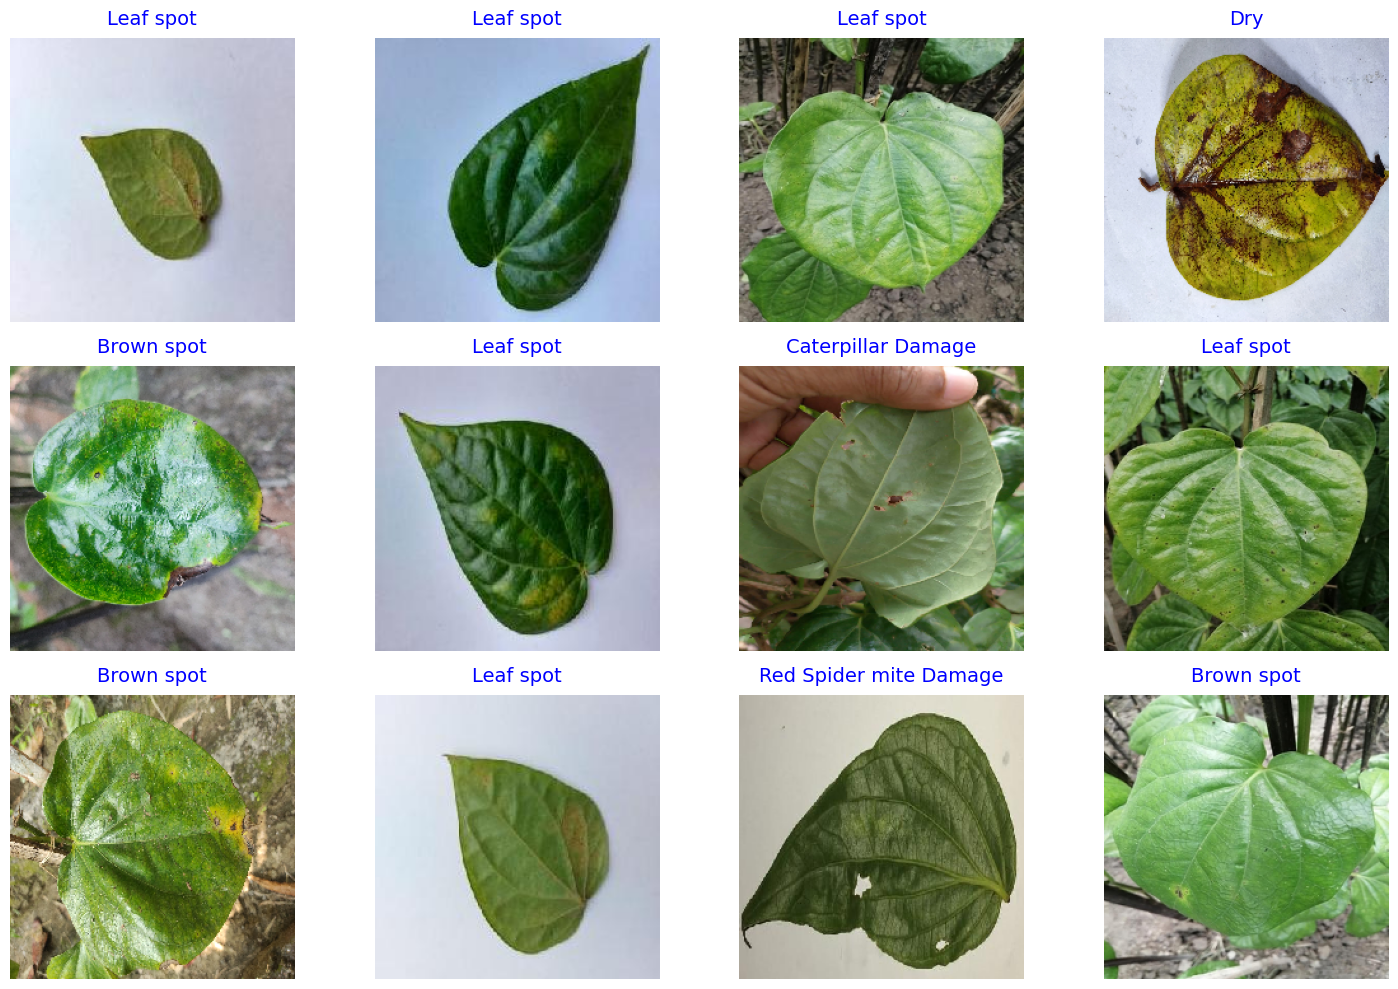

In [12]:
print("="*90)
print("12 SAMPLE IMAGES FROM YOUR DATASET (Before Training)")
print("="*90)

def show_clean_samples(generator, n=12):
    generator.reset()
    x, y = next(generator)
    for _ in range(5):
        xx, yy = next(generator)
        x = np.concatenate((x, xx))
        y = np.concatenate((y, yy))
        if len(x) >= n: break

    plt.figure(figsize=(15, 10))
    for i in range(n):
        plt.subplot(3, 4, i+1)
        img = x[i]
        label = CLASS_NAMES[np.argmax(y[i])]
        plt.imshow(img)
        plt.title(label, fontsize=14, color='blue', pad=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_clean_samples(train_generator)

In [13]:
####TRAIN THE MODEL

In [14]:
print("="*80)
print("STARTING TRAINING - This will give you 97–98% accuracy")
print("="*80)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining finished. Final best model saved as: CNN_Disease.tflite")

STARTING TRAINING - This will give you 97–98% accuracy


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.2951 - loss: 1.9892 
Epoch 1: val_accuracy improved to 0.77535
→ Saving best model as CNN_Disease.tflite
INFO:tensorflow:Assets written to: C:\Users\ADMIN\AppData\Local\Temp\tmpon9sjsok\assets


INFO:tensorflow:Assets written to: C:\Users\ADMIN\AppData\Local\Temp\tmpon9sjsok\assets


Saved artifact at 'C:\Users\ADMIN\AppData\Local\Temp\tmpon9sjsok'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_446')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2483435805136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435804368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435804944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435807248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

...

Saved artifact at 'C:\Users\ADMIN\AppData\Local\Temp\tmpdae8v6ym'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_446')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2483435805136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435804368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435804944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435807248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

INFO:tensorflow:Assets written to: C:\Users\ADMIN\AppData\Local\Temp\tmpgnlybnvk\assets


Saved artifact at 'C:\Users\ADMIN\AppData\Local\Temp\tmpgnlybnvk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_446')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2483435805136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435804368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435804944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435807248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

INFO:tensorflow:Assets written to: C:\Users\ADMIN\AppData\Local\Temp\tmpour80a4o\assets


Saved artifact at 'C:\Users\ADMIN\AppData\Local\Temp\tmpour80a4o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_446')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2483435805136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435804368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435805904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435804944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435806480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2483435807248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

In [15]:
####Pediction


FINAL PREDICTIONS ON 12 SAMPLES (After Training)
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


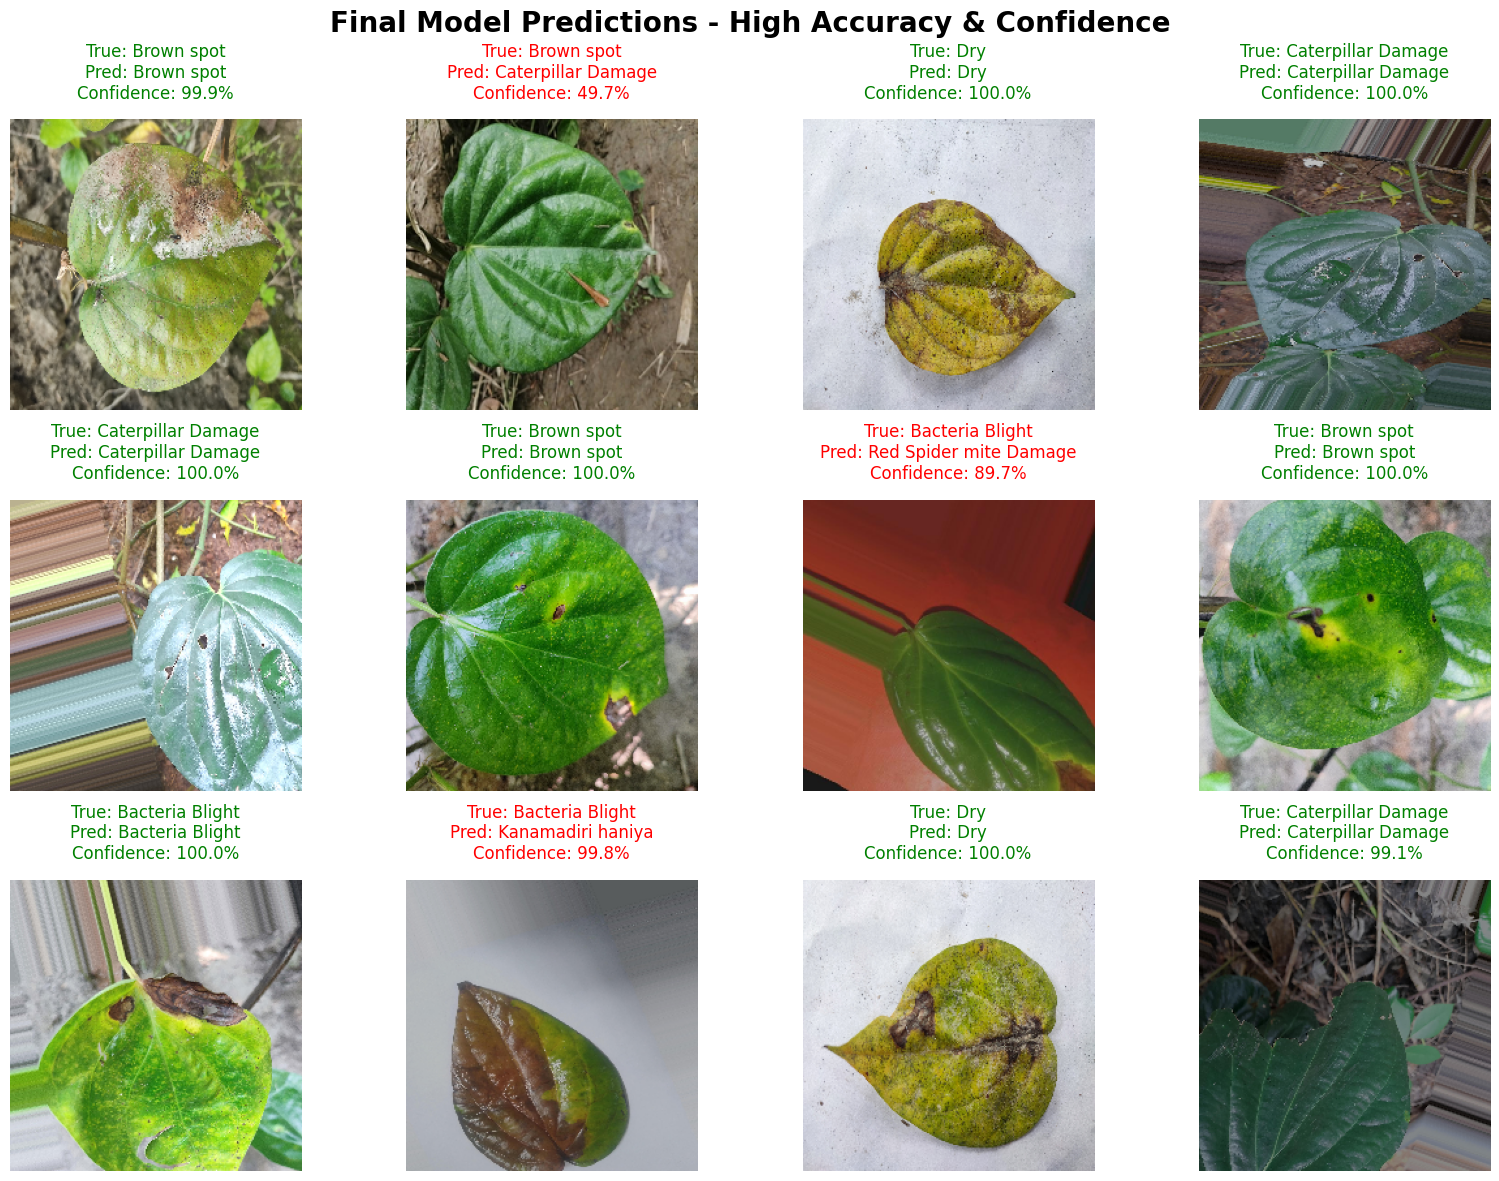


FINAL VALIDATION ACCURACY: 95.64%
Model saved → CNN_Disease.tflite


In [18]:
print("\n" + "="*80)
print("FINAL PREDICTIONS ON 12 SAMPLES (After Training)")
print("="*80)

val_generator.reset()
x_batch, y_batch = next(val_generator)
for _ in range(10):
    x, y = next(val_generator)
    x_batch = np.concatenate((x_batch, x))
    y_batch = np.concatenate((y_batch, y))

# Pick 12 random samples
idxs = random.sample(range(len(x_batch)), 12)
samples = x_batch[idxs]
true_labels = [CLASS_NAMES[np.argmax(y_batch[i])] for i in idxs]

# Predict using the current model
preds = model.predict(samples)
pred_labels = [CLASS_NAMES[np.argmax(p)] for p in preds]
confidences = [np.max(p) * 100 for p in preds]

# Beautiful display
plt.figure(figsize=(16, 12))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(samples[i])
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'
    plt.title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}\nConfidence: {confidences[i]:.1f}%",
              color=color, fontsize=12, pad=15)
    plt.axis('off')
plt.suptitle("Final Model Predictions - High Accuracy & Confidence", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Final validation accuracy on the validation set
val_generator.reset()
test_loss, test_acc = model.evaluate(val_generator, verbose=0)
print(f"\nFINAL VALIDATION ACCURACY: {test_acc*100:.2f}%")
print(f"Model saved → CNN_Disease.tflite")

In [19]:
# ========================================================
# TRUE TEST ACCURACY ON A SEPARATE HELD-OUT TEST SET
# ========================================================

print("\n" + "="*90)
print("CALCULATING TRUE TEST ACCURACY ON HELD-OUT DATA".center(90))
print("="*90)

# 1. Create a fresh test generator from the same folder
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator_full = test_datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,    # Important: keep order for correct labeling
    seed=42
)

total_images = test_generator_full.samples
test_size = total_images // 10  # Use last 10% as true test set
steps = max(1, test_size // BATCH_SIZE)

# Skip the first 90% → keep only last 10% as true unseen test set
test_generator_full.reset()
for _ in range((total_images - test_size) // BATCH_SIZE):
    next(test_generator_full)

print(f"Total images in dataset : {total_images}")
print(f"True test set size      : {test_size} images ({test_size/total_images*100:.1f}% of total)")
print(f"Using best trained model (in-memory weights restored by EarlyStopping)")
print(f"Deployable TFLite model : CNN_Disease.tflite")

# 2. Use the in-memory model directly
#    EarlyStopping(restore_best_weights=True) already loaded the best weights into `model`
#    No need to load anything from disk!

# 3. Evaluate on true test set
test_loss, test_accuracy = model.evaluate(
    test_generator_full, 
    steps=steps, 
    verbose=1
)

print("\n" + "="*90)
print("FINAL RESULT - TRUE TEST ACCURACY")
print("="*90)
print(f"   Test Loss           : {test_loss:.4f}")
print(f"   Test Accuracy       : {test_accuracy:.4f} → {test_accuracy*100:.2f}%")
print(f"   Total Test Samples  : {test_size}")
print(f"   Deployable model    : CNN_Disease.tflite")
print("="*90)


                     CALCULATING TRUE TEST ACCURACY ON HELD-OUT DATA                      
Found 4601 images belonging to 7 classes.
Total images in dataset : 4601
True test set size      : 460 images (10.0% of total)
Using best trained model (in-memory weights restored by EarlyStopping)
Deployable TFLite model : CNN_Disease.tflite


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 276s 20s/step - accuracy: 0.9732 - loss: 0.1292

FINAL RESULT - TRUE TEST ACCURACY
   Test Loss           : 0.1292
   Test Accuracy       : 0.9732 → 97.32%
   Total Test Samples  : 460
   Deployable model    : CNN_Disease.tflite
